# Imports

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

from src.initial_data import initial_data
from src.integrators import solve_ODE
from src.error import wass_2_approx

# Configuration

In [6]:
h = .015

moll_eps = 4 * h**(.99)
delta = 45 * h**(.99)

# Parameter used in psi(t), the function that maps the distribution of our initial data
tau = .02

# Parameter used in Navier-Stokes equation
nu = .1

t_step = .0625
t_max = .0625

alg = 1
num_batches = 1
ratio = 1

# Function Definitions


In [7]:
def grad_V(x, y):
    return 0

# Distribution of our initial data
def rho_0(x, y):
    return psi(0, x, y)
  
# Gaussian or Barenblatt
def psi(t, x, y):
    denom = 4 * np.pi * (tau + t)
    arg = - (x**2 + y**2) / (4 * (tau + t))
    return np.exp(arg) / denom

def exact(t, x, y):
    return psi(nu * t, x, y)

# 2nd derivative of Moreau-Yosida envelope
def f_double_prime_epsilon(x):
    return nu * x**(-1)
    
def g(r):
    r = r / delta

    return np.where(r >= 1, 1, 560 * r**26 - 5915 * r**24 
                    + 28392 * r**22 - 81796 * r**20 
                    + 157300 * r**18 - 212355 * r**16 
                    + 205920 * r**14 - 144144 * r**12
                    + 72072 * r**10 - 25025 * r**8
                    + 5720 * r**6 - 780 * r**4 
                    + 52 * r**2)




# Main


In [8]:
x0, y0, m_vals = initial_data(rho_0, .825, h)
particle_sol, runtime = solve_ODE(x0, y0, m_vals, alg, num_batches, ratio, moll_eps, f_double_prime_epsilon, grad_V, t_step, t_max, True, g) 

def func(x, y):
    return exact(t_max, x, y)
print(wass_2_approx(particle_sol[-1], m_vals, func, 1.425, .025))

Time step 1.
--- 46.530696868896484 seconds ---
0.011695581251772664


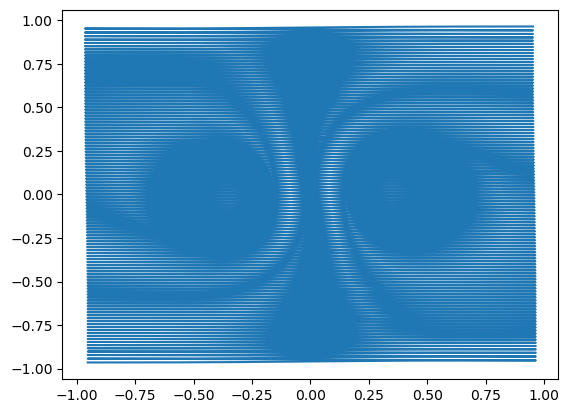

In [9]:
N = m_vals.size
plt.plot(particle_sol[-1, :N], particle_sol[-1, N:])
plt.show()